In [122]:
# messing with the hampel dates

In [123]:
#this is a generic code for looking at the continous HOBO data against the manual field measurements for one Bell Field Piezometer. Replace all of the "placeholders" with the files/parameters that you are looking for.

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
#the code chunk below installs the package that runs a hampel filter--this is what cleans the spikes out of the data caused by removing the hobo sensors from the wells

In [3]:
# pip install hampel

In [39]:
import pandas as pd
from hampel import hampel #this allows the hampel package to run

In [40]:
import os #allows python to communicate directly with the computer's operating system

In [41]:
#reading the continuous data
P1hobodf = pd.read_csv("P1_current.csv")
P1hobodf = P1hobodf.dropna()
P1hobodf["Date-Time"] = pd.to_datetime(P1hobodf["Date-Time"]) #Date-Time (CST/CDT) is the placeholder for the column with the date-time series for the x-axis. This line of code converts Date-Time (CST/CDT) to the pandas datetime format.
P1hobodf.index = pd.DatetimeIndex(P1hobodf["Date-Time"]) # This makes the the datetime column a 'datetime index', which allows us to reassign the correct dates after passing the data through the hampel filter.


In [42]:
P1hobodf['mos'] = P1hobodf.index.to_period('M')

In [43]:
P1hobodf['mos'] = P1hobodf.mos.dt.strftime('%B %Y')

In [44]:
P1hobodf.head()

,Date-Time,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids,mos
Date-Time,,,,,,,
2024-11-06 14:16:29,2024-11-06 14:16:29,13.78,3.5,4.5,0.01,2.26,November 2024
2024-11-06 14:31:29,2024-11-06 14:31:29,15.17,531.2,669.4,0.32,345.27,November 2024
2024-11-06 14:46:29,2024-11-06 14:46:29,15.23,532.8,670.4,0.32,346.32,November 2024
2024-11-06 15:01:29,2024-11-06 15:01:29,15.19,533.4,671.9,0.32,346.72,November 2024
2024-11-06 15:16:29,2024-11-06 15:16:29,15.13,533.4,672.8,0.32,346.71,November 2024


In [45]:
# the hampel filter uses a running average to compute outliers in time-dependent data. Instead of dropping outliers, it replaces them with the local average. 
P1filtered = hampel(P1hobodf["Temperature"], window_size=6, n_sigma=1.5)

In [46]:
# the hampel result has an internal index that must be stripped away to add the data back into our data frame. I convert it to a NumPy array, and then into a DataFrame with the original datetime index. (Thanks to Goodgle Gemini)
P1filtered = pd.DataFrame(P1filtered.filtered_data.to_numpy(), index=P1hobodf.index)

In [47]:
P1hobodf["FilteredTemp"] = P1filtered

In [48]:
#reading the manual data
P1mandf = pd.read_csv("Manual_Data_P1.csv", index_col=False) #Well_Sampling_Data_P1.csv is a placeholder for the csv file with the field measurements from the piezometer of interest. mandf is the placeholder for the dataframe with all of the manual field measurements. 
P1mandf["Date"] = pd.to_datetime(P1mandf["Date"]) #converts the manual date-time values to pandas datetime format. 

In [49]:
#reading in the NOAA air temp data
weatherdf = pd.read_csv("NOAAHastingsDamTemp.csv")
weatherdf["Date"] = pd.to_datetime(weatherdf["Date"])

In [50]:
weatherdf.head()

,Date,MeanTempF,MeanTempC
0,2024-07-01,64.0,17.777778
1,2024-07-02,67.5,19.722222
2,2024-07-03,66.5,19.166667
3,2024-07-04,74.5,23.611111
4,2024-07-05,66.0,18.888889


In [51]:
#reading C1 continuous data
C1hobodf = pd.read_csv("P1_creek_current.csv") 
C1hobodf["Date-Time"] = pd.to_datetime(C1hobodf["Date-Time"]) 
C1hobodf.index = pd.DatetimeIndex(C1hobodf["Date-Time"])

In [52]:
#filtering the C1 data for the outlier spikes where the hobo probe was removed from the piezometer
C1filtered = hampel(C1hobodf["Temperature"], window_size=6, n_sigma=1.5)

In [53]:
C1filtered = pd.DataFrame(C1filtered.filtered_data.to_numpy(), index=C1hobodf.index)

In [54]:
C1hobodf["FilteredTemp"] = C1filtered

In [55]:
C1hobodf['mos'] = C1hobodf.index.to_period('M')

In [56]:
C1hobodf['mos'] = C1hobodf.mos.dt.strftime('%B %Y')

In [57]:
P5hobodf = pd.read_csv('P5_current.csv')
P5hobodf = P5hobodf.dropna()
P5hobodf["Date-Time"] = pd.to_datetime(P5hobodf["Date-Time"]) 
P5hobodf.index = pd.DatetimeIndex(P5hobodf["Date-Time"]) 

In [58]:
P5filtered = hampel(P5hobodf["Temperature"], window_size=6, n_sigma=1.5)

In [59]:
P5filtered = pd.DataFrame(P5filtered.filtered_data.to_numpy(), index=P5hobodf.index)

In [60]:
P5hobodf["FilteredTemp"] = P5filtered

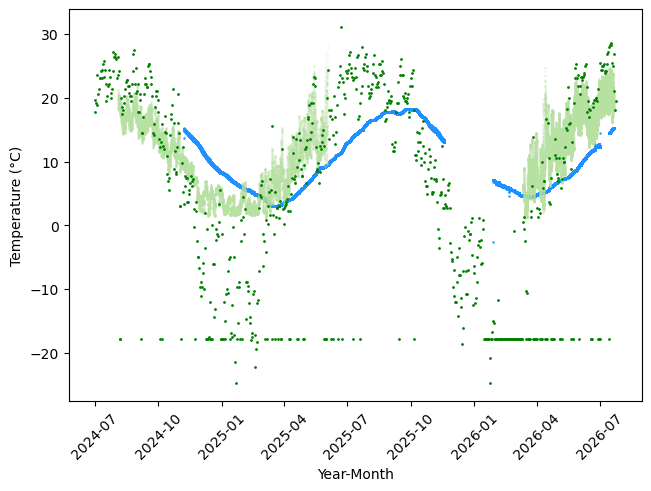

In [22]:
#creating the plot
P1mandf.columns = P1mandf.columns.str.strip() #This line was generated by Google Gemini to remove the leading and trailing whitespaces in the mandf dataframe.  


fig, ax = plt.subplots(layout='constrained')
#ax.plot(date1, filteredhobo, color="blue", label = "HOBO continuous temperature")
ax.scatter(P1hobodf.index, P1hobodf.FilteredTemp, color="dodgerblue", s = 0.5, label = "P1 continuous temperature")
ax.scatter(C1hobodf.index, C1hobodf.FilteredTemp, color = "xkcd:light grey green", alpha = 0.2, s = 0.2, label = "C1 continuous temperature")
# ax.plot(P1mandf.Date, P1mandf.loc[:,"Temp top before"], 'x', color = "orange", label = "manual temperature at top before pumping") #each variable in the manual field measurmemts data set is called by their column instead of naming each variable. The placeholders here are mandf.Date (which you should replace with the nameofdataframe.nameofcolumnfortime), mandf.loc[:,"Temp top before"] (which you should replace with nameofdataframe.loc[:, "Name of column for parameter"], and manual temperature at top before pumping (which you should replace with the name of the data for the legend). 
# ax.plot(P1mandf.Date, P1mandf.loc[:,"Temp bottom before"], 'x', color = "darkorchid", label = "manual temperature at bottom before pumping")
# ax.plot(P1mandf.Date, P1mandf.loc[:,"Temp top after"], 'o', color = "orange", label = "manual temperature at top after pumping")
# ax.plot(P1mandf.Date, P1mandf.loc[:,"Temp bottom after"], 'o', color = "darkorchid", label = "manual temperature at bottom after pumping")
ax.scatter(weatherdf.Date, weatherdf.MeanTempC, color = "green", s = 1, label = "air temperature")
# ax.plot(C1hobodfdate, C1filteredhobo, color = "xkcd:light grey green", label = "C1 continuous temperature data")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("Temperature (°C)") #Temperature (°C) is a placeholder.
# plt.xlim((pd.to_datetime("2025-11-18 06"), pd.to_datetime("2025-11-18 16")))
# plt.xlim((pd.to_datetime("2025-07-01"), pd.to_datetime("2025-07-22")))
# plt.ylim((0, 20))
# plt.xlim((pd.to_datetime("2025-10"), pd.to_datetime("2026-06")))
# plt.ylim((6, 8))

# fig.legend(loc='outside upper right') #this line puts legend outside of graph, squishes it down, but is not awful. Run with # in front to see the graph at its default dimensions.

plt.show()

In [62]:
import matplotlib.dates as mdates

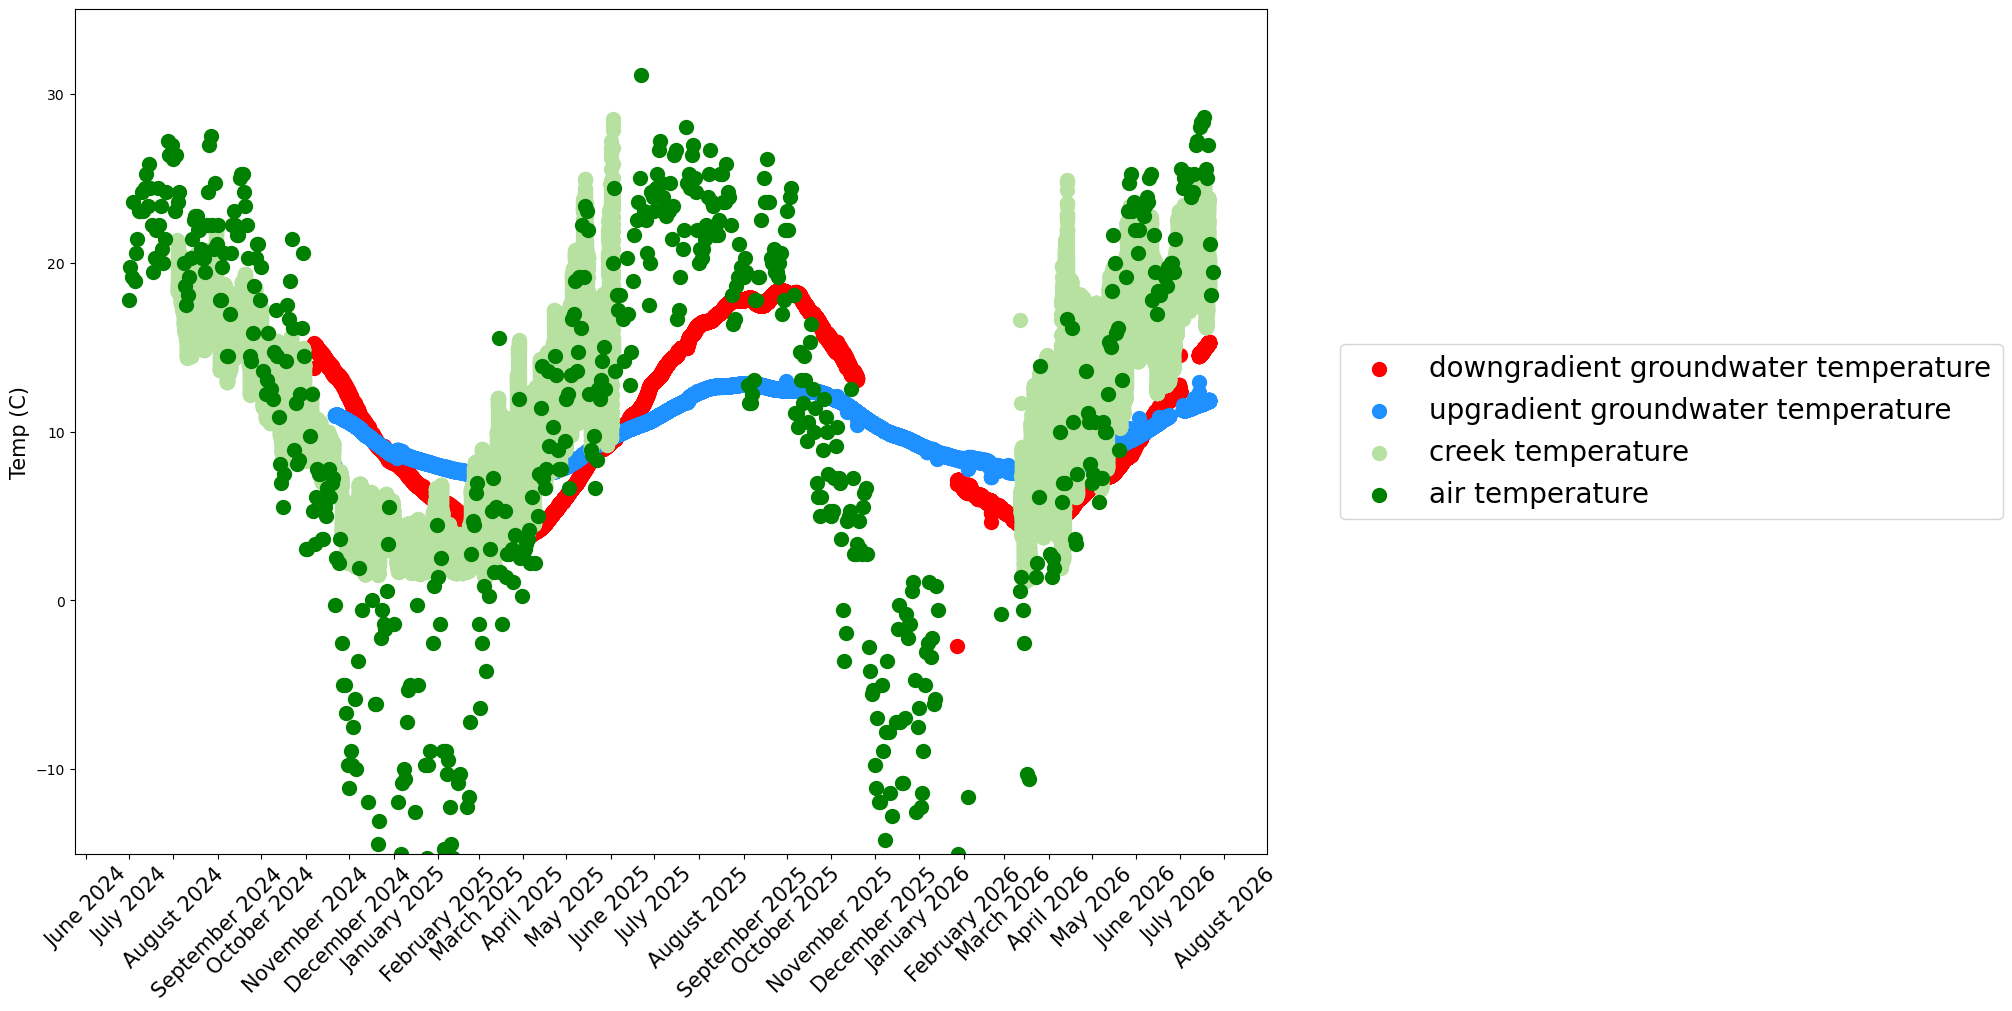

In [67]:
fig, ax = plt.subplots(layout='constrained', figsize=(20, 10))

ax.scatter(P1hobodf.index, P1hobodf.FilteredTemp, color="red", s = 100, label = "downgradient groundwater temperature")
ax.scatter(P5hobodf.index, P5hobodf.FilteredTemp, color="dodgerblue", s = 100, label = "upgradient groundwater temperature")
ax.scatter(C1hobodf.index, C1hobodf.FilteredTemp, color = "xkcd:light grey green", s = 100, label = "creek temperature")
ax.scatter(weatherdf.Date, weatherdf.MeanTempC, color = "green", s = 100, label = "air temperature")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B %Y'))

plt.xticks(rotation=45, fontsize = 15)
# plt.xlabel("Mo", fontsize = 15)
plt.ylabel("Temp (C)", fontsize = 15)
# plt.title("P5 SPC")

plt.ylim((-15, 35))
# plt.xlim((pd.to_datetime("2025-10"), pd.to_datetime("2026-02")))
#code below places legend outside graph, but squishes it
plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left", fontsize = 20)

#code below places legend on graph and covers some of the data
# ax.legend(location = "outside")

#code below puts legend outside of graph, squishes it down, but is not awful
# fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()

In [25]:
P5hobodf = pd.read_csv('P5_current.csv')
P5hobodf = P5hobodf.dropna()
P5hobodf["Date-Time"] = pd.to_datetime(P5hobodf["Date-Time"]) 
P5hobodf.index = pd.DatetimeIndex(P5hobodf["Date-Time"]) 

In [26]:
P5filtered = hampel(P5hobodf["Temperature"], window_size=6, n_sigma=1.5)

In [27]:
P5filtered = pd.DataFrame(P5filtered.filtered_data.to_numpy(), index=P5hobodf.index)

In [28]:
P5hobodf["FilteredTemp"] = P5filtered

In [29]:
#reading C5 continuous data
C5hobodf = pd.read_csv("P5_creek_cond_current.csv") 
C5hobodf["Date-Time"] = pd.to_datetime(C5hobodf["Date-Time"]) 
C5hobodf.index = pd.DatetimeIndex(C5hobodf["Date-Time"])

In [30]:
#filtering the C5 data for the outlier spikes where the hobo probe was removed from the piezometer
C5filtered = hampel(C5hobodf["Temperature"], window_size=6, n_sigma=1.5)

In [31]:
C5filtered = pd.DataFrame(C5filtered.filtered_data.to_numpy(), index=C5hobodf.index)

In [32]:
C5hobodf["FilteredTemp"] = C5filtered

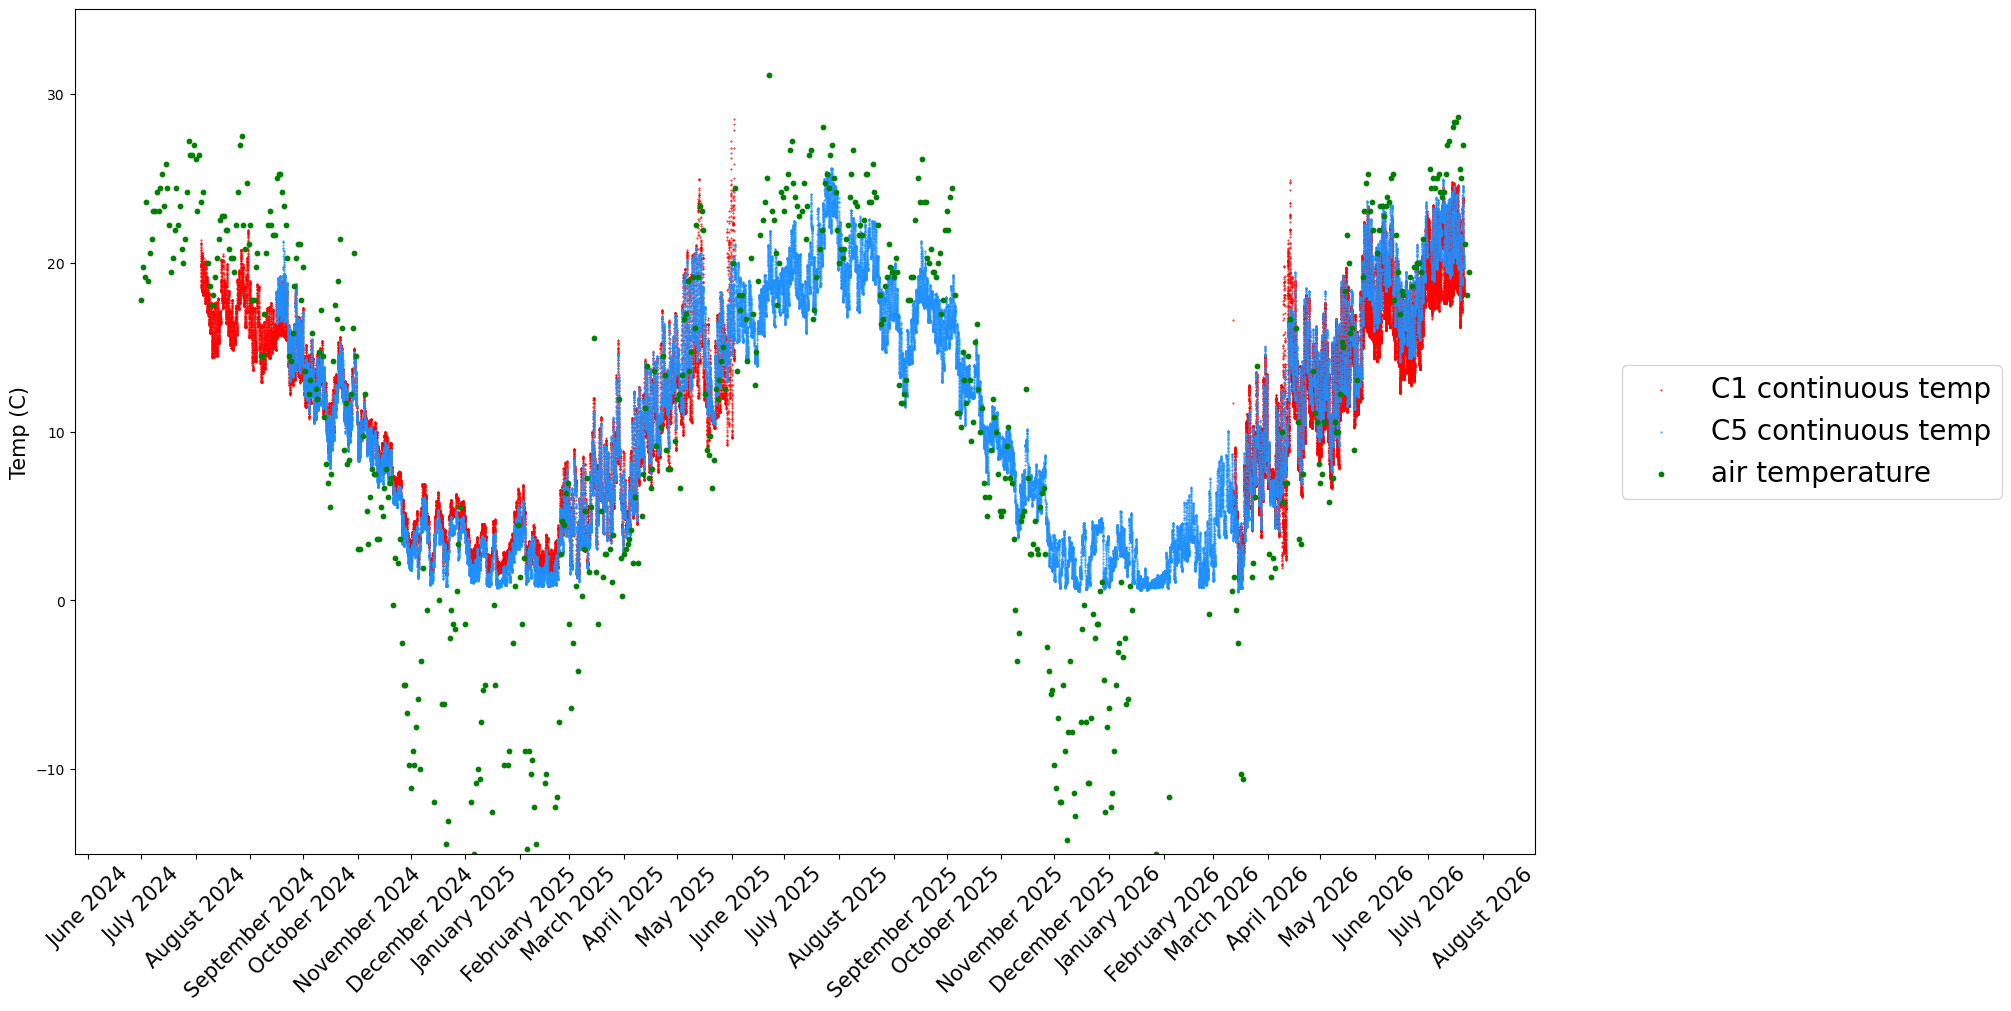

In [37]:
fig, ax = plt.subplots(layout='constrained', figsize=(20, 10))

# ax.scatter(P1hobodf.index, P1hobodf.FilteredTemp, color="red", s = 0.2, label = "P1 continuous temp")
ax.scatter(C1hobodf.index, C1hobodf.FilteredTemp, color = "red", s =0.2, label = "C1 continuous temp")
ax.scatter(C5hobodf.index, C5hobodf.FilteredTemp, color = "dodgerblue", s = 0.2, label = "C5 continuous temp")
# ax.scatter(P5hobodf.index, P5hobodf.FilteredTemp, color="dodgerblue", s = 0.2, label = "P5 continuous temp")
ax.scatter(weatherdf.Date, weatherdf.MeanTempC, color = "green", s = 10, label = "air temperature")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B %Y'))

plt.xticks(rotation=45, fontsize = 15)
# plt.xlabel("Mo", fontsize = 15)
plt.ylabel("Temp (C)", fontsize = 15)
# plt.title("P5 SPC")

plt.ylim((-15, 35))
# plt.xlim((pd.to_datetime("2025-10"), pd.to_datetime("2026-02")))
#code below places legend outside graph, but squishes it
plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left", fontsize = 20)

#code below places legend on graph and covers some of the data
# ax.legend(location = "outside")

#code below puts legend outside of graph, squishes it down, but is not awful
# fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()

In [19]:
#P1 SPC

In [20]:
#filtering the data to remove the spikes, which are the result of removing the hobo from the well during manual measurements
P1filteredSPC = hampel(P1hobodf["Specific Conductivity"], window_size=6, n_sigma=1.5)
P1filteredSPC = pd.DataFrame(P1filteredSPC.filtered_data.to_numpy(), index=P1hobodf.index)
P1hobodf["FilteredSPC"] = P1filteredSPC

In [21]:
#reading downstream continuous data
downst = pd.read_csv("Dwnstrm_current.csv") 
downst["Date-Time"] = pd.to_datetime(downst["Date-Time"]) 
downst.index = pd.DatetimeIndex(downst["Date-Time"])

In [22]:
#filtering the downstream data for the outlier spikes where the hobo probe was removed from the piezometer
downfilt = hampel(downst["Temperature"], window_size=6, n_sigma=1.5)

In [23]:
downfilt = pd.DataFrame(downfilt.filtered_data.to_numpy(), index=downst.index)

In [24]:
downstfiltSPC = hampel(downst["Specific Conductivity"], window_size=6, n_sigma=1.5)
downstfiltSPC = pd.DataFrame(downstfiltSPC.filtered_data.to_numpy(), index=downst.index)

In [25]:
downst["FilteredTemp"] = downfilt
downst["FilteredSPC"] = downstfiltSPC

In [26]:
precip = pd.read_csv("NOAAFaribaultPrecipitation.csv")
precip["Date"] = pd.to_datetime(precip["Date"])
precip = precip[precip["PrecipitationCM"] != 0]
precip.head()

,Date,PrecipitationIN,PrecipitationCM
0,2024-07-23,0.29,0.7366
1,2024-07-24,0.02,0.0508
7,2024-07-30,0.02,0.0508
9,2024-08-01,2.60,6.6040
10,2024-08-02,0.10,0.2540


AttributeError: 'DataFrame' object has no attribute 'FilteredSPC'

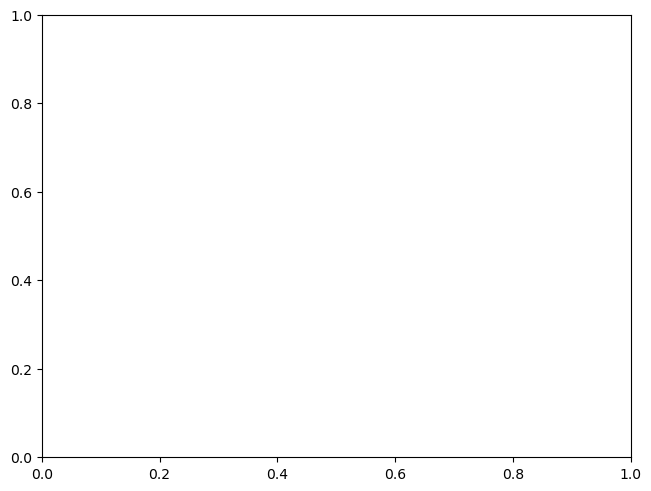

In [40]:

P1hobodate = P1hobodf["Date-Time"]
P1slicedhobodate = P1hobodate[1:]

fig, ax = plt.subplots(layout='constrained')
ax.scatter(P1hobodf.mos, P1hobodf.FilteredSPC, color="dodgerblue", s = 0.5, label = "P1 continuous SPC")
ax.plot(P1mandf.Date, P1mandf.loc[:,"SPC top before"], 'x', color = "orange", label = "manual SPC at top before pumping")
ax.plot(P1mandf.Date, P1mandf.loc[:,"SPC bottom before"], 'x', color = "darkorchid", label = "manual SPC at bottom before pumping")
ax.plot(P1mandf.Date, P1mandf.loc[:,"SPC top after"], 'o', color = "orange", label = "manual SPC at top after pumping")
ax.plot(P1mandf.Date, P1mandf.loc[:,"SPC bottom after"], 'o', color = "darkorchid", label = "manual SPC at bottom after pumping")
# down = ax2.plot(downst.index, downst.FilteredSPC,  color = "xkcd:light grey green", label = 'creek SPC at P3')
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")
plt.title("P1 SPC")
# plt.ylim((700, 750))
# plt.xlim((pd.to_datetime("2025-10"), pd.to_datetime("2026-02")))
#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()

In [1]:
fig, ax1 = plt.subplots(layout='constrained')
ax1.set_xlabel('Date (YYYY-MM-DD)')
ax1.set_ylabel('precipitation (cm)')
rain = ax1.scatter(precip.Date, precip.PrecipitationCM, alpha = 1, s= 1, color = 'tab:orange', label = "precipitation (cm)")
# ax.scatter(weatherdf.Date, weatherdf.loc[:,"Mean  Celcius Teperature"], color = "green", s = 1, label = "air temperature")

ax1.tick_params(axis='x', rotation=45)
# ax1.set_ylim(0, 3)


ax2 = ax1.twinx() 
ax2.set_ylabel('SPC (µS/cm)') 
P1 = ax2.scatter(P1hobodf.index, P1hobodf.FilteredSPC, s=1, color="dodgerblue", label = "P1 continuous SPC")
C1 = ax2.plot(downst.index, downst.FilteredSPC,  color = "xkcd:light grey green", label = 'creek SPC at P1')
down = ax2.plot(downst.index, downst.FilteredSPC,  color = "xkcd:light grey green", label = 'creek SPC at P3')

ax2.set_ylim(0, 1000)
# ax2.set_xlim((pd.to_datetime("2025-07-01"), pd.to_datetime("2025-07-22")))

plt.xticks(rotation=45)
# plt.xlabel("Year-Month")
# plt.ylabel("SPC (µS/cm)")
plt.title("P1 and C1 conductivity")
# leg = rain + C3 + C1
# labs = [l.get_label() for l in leg]
# ax1.legend(leg, labs)

# plt.xlim(pd.to_datetime("2025-04"), pd.to_datetime("2025-05"))

plt.show();

NameError: name 'plt' is not defined

In [29]:
# resampling spc so that I can plot creek against piezometer
P1hobodf.set_index('Date-Time', inplace=True)
P1hobodf.index = P1hobodf.index.round('15min')

In [30]:
P1hobodf.head()

,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids,FilteredTemp,FilteredSPC
Date-Time,,,,,,,
2024-11-06 14:15:00,13.78,3.5,4.5,0.01,2.26,13.78,4.500000
2024-11-06 14:30:00,15.17,531.2,669.4,0.32,345.27,15.17,669.400024
2024-11-06 14:45:00,15.23,532.8,670.4,0.32,346.32,15.23,670.400024
2024-11-06 15:00:00,15.19,533.4,671.9,0.32,346.72,15.19,671.900024
2024-11-06 15:15:00,15.13,533.4,672.8,0.32,346.71,15.13,672.799988


In [31]:
downst.set_index('Date-Time', inplace=True)
downst.index = downst.index.round('15min')

In [30]:
downst.head()

,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids,FilteredTemp,FilteredSPC
Date-Time,,,,,,,
2025-01-29 18:15:00,-2.775082,0.000000,0.000000,-0.004482,0.000000,-2.775082,0.000000
2025-01-29 18:30:00,4.775944,425.478851,739.583984,0.336193,276.561249,4.775944,739.583984
2025-01-29 18:45:00,5.060276,434.921082,748.230957,0.341096,282.698700,5.060276,748.230957
2025-01-29 19:00:00,4.979618,432.270203,745.843811,0.339736,280.975616,4.979618,745.843811
2025-01-29 19:15:00,4.889133,431.929840,747.708008,0.340359,280.754395,4.889133,747.708008


In [33]:
P1hobodf.index.is_unique

False

In [34]:
duplicate_rows = P1hobodf.loc[P1hobodf.index.duplicated()]
print(duplicate_rows)

# there is one repeat hour on November 02, between 1-2, because hobo loggers adjust for daylight savings. There is probably a corresponding hour missing on March 9. I am removing the second repeat for ease of plotting, so we are missing measurements for the second hour of 1 am on Nov 2. \


                     Temperature  Electrical Conductivity  \
Date-Time                                                   
2025-11-02 01:00:00        14.99                    674.1   
2025-11-02 01:15:00        15.19                    676.3   
2025-11-02 01:30:00        15.26                    676.5   
2025-11-02 01:45:00        15.10                    673.2   

                     Specific Conductivity  Salinity  Total Dissolved Solids  \
Date-Time                                                                      
2025-11-02 01:00:00                  853.5      0.41                  438.18   
2025-11-02 01:15:00                  851.7      0.41                  439.59   
2025-11-02 01:30:00                  850.6      0.41                  439.74   
2025-11-02 01:45:00                  849.9      0.41                  437.58   

                     FilteredTemp  FilteredSPC  
Date-Time                                       
2025-11-02 01:00:00         14.99   853.500000  
2025-

In [39]:
downst.to_csv(r'C:\Users\HydroResearch\Documents\GitHub\summer_26\summer 2026\downst.csv')

In [40]:
P1hobodf.to_csv(r'C:\Users\HydroResearch\Documents\GitHub\summer_26\summer 2026\P1hobodf.csv')

In [41]:
# removing the second 1 am Nov 2
downst = downst.loc[~downst.index.duplicated(keep='first')]

In [44]:
P1hobodf = P1hobodf.loc[~P1hobodf.index.duplicated(keep='first')]

In [46]:
P1hobodf = P1hobodf.reindex_like(downst, method = None)

In [47]:
P1hobodf.head()

,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids,FilteredTemp,FilteredSPC
Date-Time,,,,,,,
2025-01-29 18:15:00,6.07,541.7,899.2,0.42,352.11,6.07,899.200012
2025-01-29 18:30:00,6.02,541.6,900.5,0.42,352.07,6.02,900.500000
2025-01-29 18:45:00,5.98,541.8,902.0,0.42,352.15,5.98,902.000000
2025-01-29 19:00:00,6.07,541.5,898.8,0.42,351.97,6.07,898.799988
2025-01-29 19:15:00,5.94,541.5,902.9,0.42,351.98,5.94,900.500000


In [48]:
downst.head()

,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids,FilteredTemp,FilteredSPC
Date-Time,,,,,,,
2025-01-29 18:15:00,-2.775082,0.000000,0.000000,-0.004482,0.000000,-2.775082,0.000000
2025-01-29 18:30:00,4.775944,425.478851,739.583984,0.336193,276.561249,4.775944,739.583984
2025-01-29 18:45:00,5.060276,434.921082,748.230957,0.341096,282.698700,5.060276,748.230957
2025-01-29 19:00:00,4.979618,432.270203,745.843811,0.339736,280.975616,4.979618,745.843811
2025-01-29 19:15:00,4.889133,431.929840,747.708008,0.340359,280.754395,4.889133,747.708008


In [49]:
print("X shape:", downst.FilteredSPC.shape, "Total size:", downst.FilteredSPC.size)
print("Y shape:", P1hobodf.FilteredSPC.shape, "Total size:", P1hobodf.FilteredSPC.size)

X shape: (51475,) Total size: 51475
Y shape: (51475,) Total size: 51475


In [50]:
downst['mos'] = downst.index.to_period('M')

In [51]:
downst['mos'] = downst.mos.dt.strftime('%B %Y')

In [52]:
downst

,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids,FilteredTemp,FilteredSPC,mos
Date-Time,,,,,,,,
2025-01-29 18:15:00,-2.775082,0.000000,0.000000,-0.004482,0.000000,-2.775082,0.000000,January 2025
2025-01-29 18:30:00,4.775944,425.478851,739.583984,0.336193,276.561249,4.775944,739.583984,January 2025
2025-01-29 18:45:00,5.060276,434.921082,748.230957,0.341096,282.698700,5.060276,748.230957,January 2025
2025-01-29 19:00:00,4.979618,432.270203,745.843811,0.339736,280.975616,4.979618,745.843811,January 2025
2025-01-29 19:15:00,4.889133,431.929840,747.708008,0.340359,280.754395,4.889133,747.708008,January 2025
...,...,...,...,...,...,...,...,...
2026-07-21 08:45:00,18.341282,492.681305,572.774048,0.275185,320.242828,18.341282,572.774048,July 2026
2026-07-21 09:00:00,18.314548,492.425110,572.850098,0.275207,320.076324,18.344273,572.850098,July 2026
2026-07-21 09:15:00,18.323460,493.912476,574.455383,0.276003,321.043091,18.323460,574.455383,July 2026


In [53]:
P1hobodf['mos'] = P1hobodf.index.to_period('M')

In [54]:
P1hobodf['mos'] = P1hobodf.mos.dt.strftime('%B %Y')

In [55]:
P1hobodf

,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids,FilteredTemp,FilteredSPC,mos
Date-Time,,,,,,,,
2025-01-29 18:15:00,6.070000,541.700000,899.200000,0.420000,352.110000,6.070000,899.200012,January 2025
2025-01-29 18:30:00,6.020000,541.600000,900.500000,0.420000,352.070000,6.020000,900.500000,January 2025
2025-01-29 18:45:00,5.980000,541.800000,902.000000,0.420000,352.150000,5.980000,902.000000,January 2025
2025-01-29 19:00:00,6.070000,541.500000,898.800000,0.420000,351.970000,6.070000,898.799988,January 2025
2025-01-29 19:15:00,5.940000,541.500000,902.900000,0.420000,351.980000,5.940000,900.500000,January 2025
...,...,...,...,...,...,...,...,...
2026-07-21 08:45:00,15.283695,657.136780,825.592712,0.398137,427.138885,15.283695,825.592712,July 2026
2026-07-21 09:00:00,15.286686,656.930176,825.268005,0.397979,427.004608,15.286686,825.268005,July 2026
2026-07-21 09:15:00,15.286686,657.096069,825.476379,0.398083,427.112427,15.286686,825.476379,July 2026


In [58]:
month = downst.mos.unique()

In [59]:
print(month)

<StringArray>
[  'January 2025',  'February 2025',     'March 2025',     'April 2025',
       'May 2025',      'June 2025',      'July 2025',    'August 2025',
 'September 2025',   'October 2025',  'November 2025',  'December 2025',
   'January 2026',  'February 2026',     'March 2026',     'April 2026',
       'May 2026',      'June 2026',      'July 2026']
Length: 19, dtype: str


In [71]:
colors = {'January 2025':'#ff5e00', 'February 2025':'#ffa400', 'March 2025': '#ffea00', 'April 2025':'#cdff00', 'May 2025':'#8dff00', 'June 2025':'#46ff00', 'July 2025':'#00ff00', 'August 2025':'#00ff46', 'September 2025':'#00ff8c', 'October 2025':'#00ffcc', 'November 2025': '#00ecff', 'December 2025':'#00a5ff', 'January 2026':'#005eff', 'February 2026':'#0018ff', 'March 2026':'#2a00ff', 'April 2026':'#7000ff', 'May 2026':'#b700ff', 'June 2026':'#fe00ff', 'July 2026':'#ff00bf'}

In [60]:
left = downst
right = P1hobodf

In [61]:
stat1 = pd.merge(left, right, on = 'Date-Time')

In [62]:
stat1

,Temperature_x,Electrical Conductivity_x,Specific Conductivity_x,Salinity_x,Total Dissolved Solids_x,FilteredTemp_x,FilteredSPC_x,mos_x,Temperature_y,Electrical Conductivity_y,Specific Conductivity_y,Salinity_y,Total Dissolved Solids_y,FilteredTemp_y,FilteredSPC_y,mos_y
Date-Time,,,,,,,,,,,,,,,,
2025-01-29 18:15:00,-2.775082,0.000000,0.000000,-0.004482,0.000000,-2.775082,0.000000,January 2025,6.070000,541.700000,899.200000,0.420000,352.110000,6.070000,899.200012,January 2025
2025-01-29 18:30:00,4.775944,425.478851,739.583984,0.336193,276.561249,4.775944,739.583984,January 2025,6.020000,541.600000,900.500000,0.420000,352.070000,6.020000,900.500000,January 2025
2025-01-29 18:45:00,5.060276,434.921082,748.230957,0.341096,282.698700,5.060276,748.230957,January 2025,5.980000,541.800000,902.000000,0.420000,352.150000,5.980000,902.000000,January 2025
2025-01-29 19:00:00,4.979618,432.270203,745.843811,0.339736,280.975616,4.979618,745.843811,January 2025,6.070000,541.500000,898.800000,0.420000,351.970000,6.070000,898.799988,January 2025
2025-01-29 19:15:00,4.889133,431.929840,747.708008,0.340359,280.754395,4.889133,747.708008,January 2025,5.940000,541.500000,902.900000,0.420000,351.980000,5.940000,900.500000,January 2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-21 08:45:00,18.341282,492.681305,572.774048,0.275185,320.242828,18.341282,572.774048,July 2026,15.283695,657.136780,825.592712,0.398137,427.138885,15.283695,825.592712,July 2026
2026-07-21 09:00:00,18.314548,492.425110,572.850098,0.275207,320.076324,18.344273,572.850098,July 2026,15.286686,656.930176,825.268005,0.397979,427.004608,15.286686,825.268005,July 2026
2026-07-21 09:15:00,18.323460,493.912476,574.455383,0.276003,321.043091,18.323460,574.455383,July 2026,15.286686,657.096069,825.476379,0.398083,427.112427,15.286686,825.476379,July 2026


In [ ]:
stat1["mos_x"], unique_categories = pd.factorize(df["category_column"])

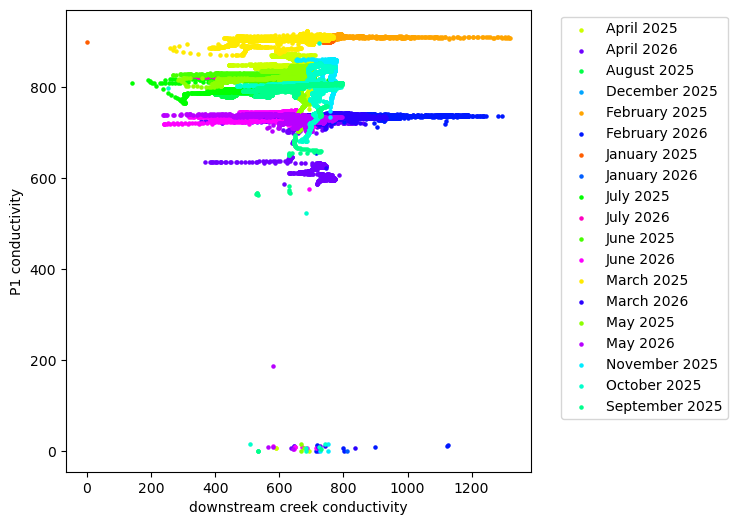

In [76]:
# Source - https://stackoverflow.com/a/26139658
# Posted by Ffisegydd, modified by community. See post 'Timeline' for change history
# Retrieved 2026-07-29, License - CC BY-SA 4.0

fig, ax = plt.subplots(figsize=(6, 6))

grouped = stat1.groupby('mos_x')
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='Specific Conductivity_x', y='Specific Conductivity_y', s = 5, label=key, color=colors[key])

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel('P1 conductivity')
plt.xlabel('downstream creek conductivity')
plt.show()


ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not <StringArray>
[  'January 2025',  'February 2025',     'March 2025',     'April 2025',
       'May 2025',      'June 2025',      'July 2025',    'August 2025',
 'September 2025',   'October 2025',  'November 2025',  'December 2025',
   'January 2026',  'February 2026',     'March 2026',     'April 2026',
       'May 2026',      'June 2026',      'July 2026']
Length: 19, dtype: str

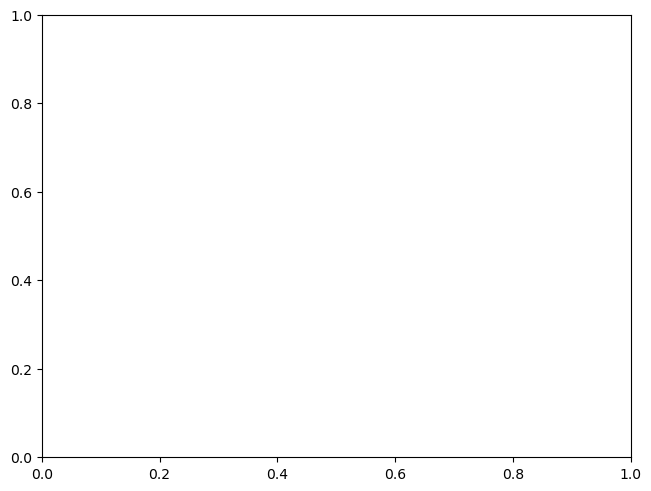

In [159]:
fig, ax = plt.subplots(layout='constrained')

plot = ax.scatter(downst.FilteredSPC, P1hobodf.FilteredSPC, s= 1, c = month, cmap = 'Set3') 
plt.ylabel("daily average downstream SPC") 
plt.xlabel("daily average P1 SPC")

cbar = plt.colorbar(plot)
ticks = [downst.month.unique]
cbar.set_ticks(ticks)

plt.plot()

In [160]:
import seaborn as sns

In [165]:
import matplotlib.colors as colors

In [167]:
import matplotlib.cm as cmx

In [168]:
z = range(1,len(month))
hot = plt.get_cmap('hot')
cNorm  = colors.Normalize(vmin=0, vmax=len(month))
scalarMap = cmx.ScalarMappable(norm=cNorm, cmap=hot)

In [169]:
month = list(set(downst['mos']))

In [171]:
for i in r 

IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).